# Data

> Data classes and functions

In [1]:
#| default_exp data

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| export

from fastai.vision.all import *
from fastai.data.all import *
from torchio import ScalarImage, ToCanonical, Resample
import multipagetiff as mtif


## Utilities

### Tiff reader

In [4]:
#| export

def tiff_reader(path,  # The path to the TIFF file to be read
                units='um',  # The units for the image data.
               ):

    """
    Reads a TIFF file and returns the image data along with an identity affine matrix.

    #### Parameters
    path (str): The path to the TIFF file to be read.
    units (str, optional): The units for the image data. Default is 'um' (micrometers).

    #### Returns
    tuple: A tuple containing:
        - data (numpy.ndarray): The image data read from the TIFF file as a 4D array (1, Z, Y, X).
        - affine (numpy.ndarray): A 4x4 identity affine matrix.
    """

    # Read the TIFF stack using mtif.read_stack with the specified units
    stack = mtif.read_stack(path, units=units)

    # Convert the stack pages to a NumPy array of type float32
    data = stack.pages.astype(np.float32)

    # Add a new axis to the data to make it a 4D array (1, Z, Y, X)
    data = data[None, :, :, :]

    # Create a 4x4 identity affine matrix
    affine = np.eye(4) # to be changed

    # Return the image data and the affine matrix
    return data, affine

In [5]:
# file_path = '../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff'

# d, _ = tiff_reader(file_path)

### Lif reader

In [6]:
#| export
from aicsimageio import AICSImage

def lif_reader(path, # The path to the LIF file to be read
               units='um', # The units for the image data.
               scene=0, # The scene index to be read from the LIF file
               time=0, # The time index to be read from the LIF file
               reconstruct_mosaic=False, # Whether to reconstruct a mosaic image from the file
              ):

    """
    Reads a LIF (Leica Image File) and returns the image data along with an identity affine matrix.

    Parameters:
    path (str): The path to the LIF file to be read.
    units (str, optional).
    scene (int, optional): The scene index to be read from the LIF file. Default is 0.
    time (int, optional): The time index to be read from the LIF file. Default is 0.
    reconstruct_mosaic (bool, optional): Whether to reconstruct a mosaic image from the file. Default is False.

    Returns:
    tuple: A tuple containing:
        - data (numpy.ndarray): The image data read from the LIF file in ZYX format.
        - affine (numpy.ndarray): A 4x4 identity affine matrix.
    """
    # Create an AICSImage object for the specified file
    imagen_aics = AICSImage(path, reconstruct_mosaic=reconstruct_mosaic)
    # set scence

    # Retrieve the image data in ZYX format for the specified time point
    data = imagen_aics.get_image_data("ZYX", T=time) 
    
    # Create a 4x4 identity affine matrix
    affine = np.eye(4)

    # Return the image data and the affine matrix
    return data, affine

In [7]:
# file_path_2 = '../../bioMONAI_0/_data/Babesia_new/Sample_02/Stellaris/Reflection+Fluo_20221205/2022-12-05.lif'

# e, _ = lif_reader(file_path_2, units='um')


### CZI reader

In [8]:
#| export
from aicsimageio.readers import CziReader

def czi_reader(path, # The path to the CZI file to be read
              ):

    """
    Reads a CZI (Zeiss CZI format) file and returns the image data along with an identity affine matrix.

    Parameters:
    path (str): The path to the CZI file to be read.

    Returns:
    tuple: A tuple containing:
        - data (numpy.ndarray): The image data read from the CZI file.
        - affine (numpy.ndarray): A 4x4 identity affine matrix.
    """

    # Create a CziReader for the specified file
    reader = CziReader(path)

    # Convert the file to a Numpy Array
    data = reader.data  

    # Create a 4x4 identity affine NumpyArray
    affine = np.eye(4)

    # Return the image data and the affine matrix
    return data, affine

In [9]:
# file_path_3 = '../../bioMONAI_0/_data/Babesia_new/Image_1_2023_08_18__14_32_31_964(1).czi'

# f, _ = czi_reader(file_path_3)



### Image Reader

In [10]:
#| export

def _image_reader(path, # The file path to the image             
                 ):

    """
    Reads an image from the specified path using AICSImage library.

    Parameters:
        path (str): The file path to the image.

    Returns:
        tuple: A tuple containing the image data and its affine transformation matrix.
               The image data is a NumPy array representing the image.
               The affine transformation matrix is a 4x4 NumPy array.
    """

    # Read image using AICSImage library
    image_aics = AICSImage(path, reconstruct_mosaic=False)
        
    # Support for tiff files    
    path = str(path)
    if (path[-4:]=="tiff"):

        # Reorder for tiff files
        data = image_aics.get_image_data("CZYX", T=0)  # returns 4D CZYX numpy array
        
        affine = np.eye(4) #to change
        
        return data, affine

    # Convert to numpy array    
    data = image_aics.data

    # Remove singleton dimensions
    data = np.squeeze(data)
    
    # Create an identity affine transformation matrix
    affine = np.eye(4)

    # Return the image data and the affine matrix
    return data, affine


In [11]:
# file_path = '../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff'

# f, _ = _image_reader(file_path)


### H5 Reader

In [12]:
#| export
import h5py

def h5_reader(path, dataset):
    with h5py.File(path, 'r') as hdf:
            ls = list(hdf.keys())
            print('List of datasets in this file: \n',ls)
            data = hdf.get(dataset)
            dataset1 = np.array(data)
            print('Shape of dataset1: \n', dataset1.shape)

    return dataset1


In [13]:
# f = h5_reader('/home/juanlocal/hdf5_data.h5','dataset1')


### Preprocessing

In [14]:
#| export

def _preprocess(obj, # The object to preprocess
                reorder, # Whether to reorder the object
                resample # Whether to resample the object
               ):
    """
    Preprocesses the given object.

    Args:
        obj: The object to preprocess.
        reorder: Whether to reorder the object.
        resample: Whether to resample the object.

    Returns:
        The preprocessed object and its original size.
    """
    if reorder:
        transform = ToCanonical()
        obj = transform(obj)
    


    original_size = obj.shape[1:]

    if resample and not all(np.isclose(obj.spacing, resample)):
        transform = Resample(resample)
        obj = transform(obj)

    # if MedBase.affine_matrix is None:
    #     MedBase.affine_matrix = obj.affine

    return obj, original_size


### Load and preprocess

In [15]:
#| export

def _load_and_preprocess(file_path, # Image file path
                         reorder=False, # Whether to reorder data for canonical (RAS+) orientation
                         resample=False, # Whether to resample image to different voxel sizes and dimensions
                         reader=_image_reader # Whether to resample image to different voxel sizes and dimensions
                        ):
    """
    Helper function to load and preprocess an image.

    Args:
        file_path: Image file path.
        reorder: Whether to reorder data for canonical (RAS+) orientation.
        resample: Whether to resample image to different voxel sizes and dimensions.
        dtype: Desired datatype for output.

    Returns:
        tuple: Original image, preprocessed image, and its original size.
    """
    org_img = ScalarImage(file_path, reader=reader)
    input_img, org_size = _preprocess(org_img, reorder, resample)
    
    return org_img, input_img, org_size


In [16]:
# load and process any file
# org_img, input_img, org_size = _load_and_preprocess(file_path)


### Read multichannel data

In [17]:
#| export

def _multi_channel(image_paths: (L, list), # List of image paths (e.g., T1, T2, T1CE, DWI)
                   reorder: bool = False, # Whether to reorder data for canonical (RAS+) orientation
                   resample: list = None, # Whether to resample image to different voxel sizes and dimensions
                   dtype=torch.Tensor, # Desired datatype for output
                   only_tensor: bool = True, # Whether to return only image tensor
                   squeeze: bool = False # 
                  ):
    """
    Load and preprocess multisequence data.

    Args:
        image_paths: List of image paths (e.g., T1, T2, T1CE, DWI).
        reorder: Whether to reorder data for canonical (RAS+) orientation.
        resample: Whether to resample image to different voxel sizes and dimensions.
        dtype: Desired datatype for output.
        only_tensor: Whether to return only image tensor.
        squeeze: Whether to squeeze or not the image

    Returns:
        torch.Tensor: A stacked 4D tensor, if `only_tensor` is True.
        tuple: Original image, preprocessed image, original size, if `only_tensor` is False.
    """
    image_data = [_load_and_preprocess(image, reorder, resample) for image in image_paths]
    org_img, input_img, org_size = image_data[-1]

    tensor = torch.stack([img.data[0] for _, img, _ in image_data], dim=0)

    if only_tensor:     
        if squeeze:
            return torch.squeeze(dtype(tensor))
        return dtype(tensor) 

    input_img.set_data(tensor)
    return org_img, input_img, org_size

---

[source](https://github.com/bmandracchia/bioMONAI/blob/main/bioMONAI/data.py#L232){target="_blank" style="float:right; font-size:smaller"}

### _multi_channel

>      _multi_channel
>                      (image_paths:(<class'fastcore.foundation.L'>,<class'list'
>                      >), reorder:bool=False, resample:list=None, dtype=<class
>                      'torch.Tensor'>, only_tensor:bool=True,
>                      squeeze:bool=False)

Load and preprocess multisequence data.

Args:
    image_paths: List of image paths (e.g., T1, T2, T1CE, DWI).
    reorder: Whether to reorder data for canonical (RAS+) orientation.
    resample: Whether to resample image to different voxel sizes and dimensions.
    dtype: Desired datatype for output.
    only_tensor: Whether to return only image tensor.
    squeeze: Whether to squeeze or not the image

Returns:
    torch.Tensor: A stacked 4D tensor, if `only_tensor` is True.
    tuple: Original image, preprocessed image, original size, if `only_tensor` is False.

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| image_paths | (<class 'fastcore.foundation.L'>, <class 'list'>) |  | List of image paths (e.g., T1, T2, T1CE, DWI) |
| reorder | bool | False | Whether to reorder data for canonical (RAS+) orientation |
| resample | list | None | Whether to resample image to different voxel sizes and dimensions |
| dtype | _TensorMeta | Tensor | Desired datatype for output |
| only_tensor | bool | True | Whether to return only image tensor |
| squeeze | bool | False |  |

In [18]:
# file_names = get_image_files('../../bioMONAI_0/_data/Babesia/TRITC')#'../_data/Babesia/TRITC'

# _multi_channel(file_names);

### Image reader

In [19]:
#| export

def img_reader(file_path: (str, Path, L, list), # Path to the image
               dtype=torch.Tensor, # Datatype for the return value. Defaults to torch.Tensor
               reorder: bool = False, # Whether to reorder to canonical orientation
               resample: list = None, # Whether to resample image to different voxel sizes and image dimensions
               only_tensor: bool = True, # To return only an image tensor
              ):
    """Loads and preprocesses a medical image.

    Args:
        file_path: Path to the image. Can be a string, Path object or a list.
        dtype: Datatype for the return value. Defaults to torch.Tensor.
        reorder: Whether to reorder the data to be closest to canonical 
            (RAS+) orientation. Defaults to False.
        resample: Whether to resample image to different voxel sizes and 
            image dimensions. Defaults to None.
        only_tensor: To return only an image tensor. Defaults to True.

    Returns:
        The preprocessed image. Returns only the image tensor if 
        only_tensor is True, otherwise returns original image, 
        preprocessed image, and original size.
    """
    # if isinstance(file_path, str) and ';' in file_path:
    #     return _multi_channel(
    #         file_path.split(';'), reorder, resample, dtype, only_tensor)
    
    if isinstance(file_path, (L, list)):
        return _multi_channel(file_path, reorder, resample, dtype, only_tensor)

    org_img, input_img, org_size = _load_and_preprocess(
        file_path, reorder, resample)

    if only_tensor:
        return dtype(input_img.data.type(torch.float))

    return org_img, input_img, org_size


In [20]:
#img_reader(file_path_2)

## Data types

### Meta resolver

In [21]:
#| export

class MetaResolver(type(torch.Tensor), metaclass=BypassNewMeta):
    """
    A class to bypass metaclass conflict:
    https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/data/batch.html
    """
    pass
    

### BioImageBase

In [22]:
#| export

from bioMONAI.core import show_images_grid, mosaic_image_3d
from monai.data import MetaTensor


In [23]:

#| export
class BioImageBase(MetaTensor, metaclass=MetaResolver):
    """
    A class that represents an image object.
    Metaclass casts `x` to this class if it is of type `cls._bypass_type`.
    """
    
    _bypass_type = torch.Tensor  # The type that bypasses image loading
    _show_args = {'cmap': 'gray'}  # Default arguments for image display
    resample, reorder = None, False  # Default resample and reorder settings
    affine_matrix = None  # Default affine matrix for image transformation

    @classmethod
    def create(cls, fn: (Path, str, List, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 4D tensor as a BioImageBase object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)

    @classmethod
    def item_preprocessing(cls, resample: (List, int, tuple), reorder: bool):
        """
        Changes the values for the class variables `resample` and `reorder`.

        Args:
            resample : (List, int, tuple)
                A list with voxel spacing.
            reorder : bool
                Whether to reorder the data to be closest to canonical (RAS+) orientation.
        """
        cls.resample = resample
        cls.reorder = reorder

    def show(self, ctx=None, figsize: int = None, ncols: int = 10, **kwargs):
        """
        Plots 2D slices of a 3D image alongside a prior specified axis.

        Args:
            ctx : Context to use for the display. Defaults to None.
            figsize: Size of the figure. Defaults to None.
            ncols: Number of columns in the grid. Defaults to 10.
            **kwargs : Additional keyword arguments passed to plt.imshow.

        Returns:
            Shown image.
        """
        return show_images_grid(self, ctx=ctx, ncols=ncols, **merge(self._show_args, kwargs))
    
    def as_tensor(self) -> torch.Tensor:
        """
        Return the `MetaTensor` as a `torch.Tensor`.
        It is OS dependent as to whether this will be a deep copy or not.
        """
        return self.as_subclass(torch.Tensor)

    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageBase{self.as_tensor().__repr__()[6:]}"

### BioImage 

class for 2D Images

In [24]:
#| export

class BioImage(BioImageBase):
    """Subclass of BioImageBase that represents 2D and 3D image objects."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
    #     return f'{self.__class__.__name__} shape={"x".join([str(d) for d in self.shape])}'
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [25]:
# a = BioImage.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
# print(a.shape)
# a = BioImage.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
# a.shape

### BioImageStack

class for 3D images

In [26]:
#| export

class BioImageStack(BioImageBase):
    """Subclass of BioImageBase that represents a 3D image object."""
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageStack{self.as_tensor().__repr__()[6:]}"

In [27]:
# a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
# print(a.shape)
# a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
# a.shape

### BioImageProject

2D representations of 3D stack using maximum intensity projection

In [28]:
#| export

class BioImageProject(BioImageBase):
    """Subclass of BioImageBase that represents a 2D image object."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        img = img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)
        return torch.max(img, dim=1)[0]  # Taking the maximum intensity projection along axis 1
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [29]:
# a = BioImageProject.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
# a.shape

### BioImageMulti

Multichannel datasets

In [30]:
#| export

class BioImageMulti(BioImageBase):
    """Subclass of BioImageBase that represents a multi-channel 2D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 0)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageMulti{self.as_tensor().__repr__()[6:]}"
        

In [31]:
# a = BioImageMulti.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(a.shape)

### BioImage4D

4D datasets

In [32]:
# TO DO

class BioImage4D(BioImageBase):
    """Subclass of BioImageBase that represents a (multi-channel) 3D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage4D{self.as_tensor().__repr__()[6:]}"

In [33]:
# a = BioImage4D.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(a.shape)


tensor = torch.randn(3,10, 4, 5)
b = BioImage4D.create(tensor)#'../_data/Babesia/RI/O11_RI_frame01.tiff'
print(b.shape)

torch.Size([3, 10, 4, 5])


### Data conversion

In [34]:
#| export

class Tensor2BioImage(DisplayedTransform):
    def __init__(self, cls:BioImageBase=BioImageStack):
        self.cls = cls

    def encodes(self, o):
        if isinstance(o, MetaTensor):
            return self.cls(o.clone(), affine=o.affine, meta=o.meta)
        
        if isinstance(o, torch.Tensor):
            return self.cls(o)

## Data blocks

### ImageBlock

In [35]:
#| export

def BioImageBlock(cls:BioImageBase=BioImageStack):
    "A `TransformBlock` for images of `cls`"
    return TransformBlock(type_tfms=cls.create, batch_tfms=[Tensor2BioImage(cls)]) # IntToFloatTensor

## Display

### Show batch

In [36]:
#| export 

@typedispatch
def show_batch(x:BioImageBase, y:BioImageBase, samples, ctxs=None, max_n=10, nrows=None, ncols=None, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    for i in range(2):
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::2],range(max_n))]
    return ctxs

### Show results

In [37]:
#| export 

@typedispatch
def show_results(x:BioImageBase, y:BioImageBase, samples, outs, ctxs=None, max_n=10, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(3*min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::3],range(max_n))]
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(outs.itemgot(0),ctxs[2::3],range(max_n))]
    return ctxs

## Example

In [38]:
from monai.transforms import ScaleIntensity
from bioMONAI.transforms import *

In [ ]:
spatial_dimensions = 2
roi_size = [32]*spatial_dimensions
item_tfms = [RandCropND(roi_size), ScaleIntensity] 

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


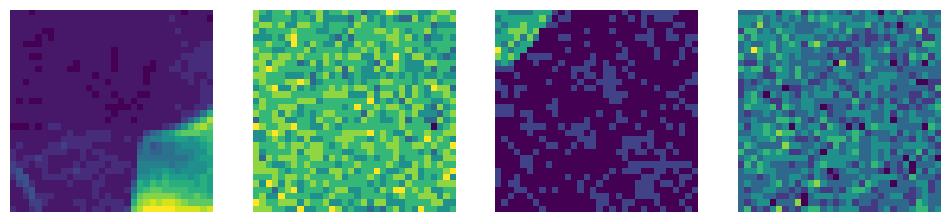

In [39]:
from bioMONAI.core import get_target

In [ ]:
file_folder = '../_data/Babesia/RI/'

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImageProject)),
                   get_items=get_image_files,
                   get_y=get_target('../_data/Babesia/TRITC', same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )
# dblock.summary(file_folder)

dls = dblock.dataloaders(file_folder, bs=2)
dls.show_batch(max_n=2, cmap='viridis')

In [40]:
from monai.networks.nets import DynUNet
from monai.losses import SSIMLoss

In [41]:
model = DynUNet(spatial_dims=spatial_dimensions, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True)

In [42]:
loss_func = SSIMLoss(spatial_dims=spatial_dimensions)

In [43]:
learn = Learner(dls, model, loss_func=loss_func)

In [44]:
learn.summary()

Setting affine, but the applied meta contains an affine. This will be overwritten.


Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)


DynUNet (Input shape: 2 x 1 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     2 x 32 x 32 x 32    
Conv2d                                    288        True      
Conv2d                                    9216       True      
LeakyReLU                                                      
InstanceNorm2d                            64         True      
InstanceNorm2d                            64         True      
Conv2d                                    32         True      
InstanceNorm2d                            64         True      
____________________________________________________________________________
                     2 x 64 x 16 x 16    
Conv2d                                    18432      True      
Conv2d                                    36864      True      
LeakyReLU                                                      
InstanceNorm2d                            128        True      
InstanceNorm2d                  

In [45]:
learn.fit_flat_cos(5,1e-3)

epoch,train_loss,valid_loss,time
0,0.933055,0.571958,00:06
1,0.257485,0.112305,00:07
2,0.105427,0.036427,00:07
3,0.091262,0.041423,00:07
4,0.078249,0.048581,00:07


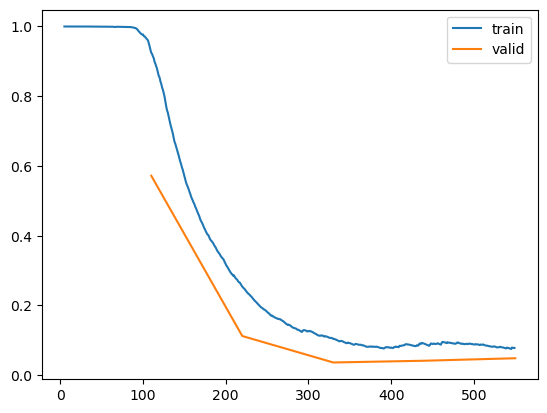

In [46]:
learn.recorder.plot_loss()

Setting affine, but the applied meta contains an affine. This will be overwritten.


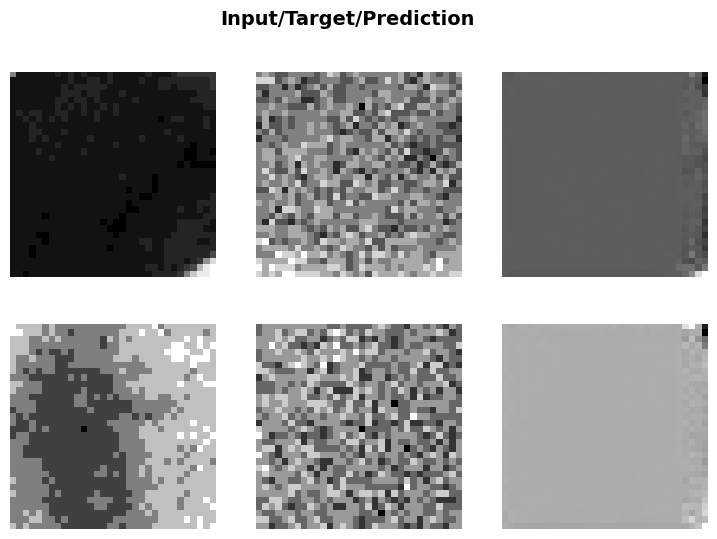

In [47]:
learn.show_results(cmap='gray')

In [1]:
#| hide
import nbdev; nbdev.nbdev_export()